In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [8]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [9]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [23]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

C:\Users\hp\AppData\Local\Temp\ipykernel_33088\3090101260.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values


ValueError: cannot set using a list-like indexer with a different length than the value

In [24]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([52.  , 29.  , 21.  ,  9.  , 33.  , 30.  , 40.5 , 19.  , 48.  ,
       19.  , 36.  , 58.  , 29.  , 30.  , 54.  , 20.  , 20.  ,  7.  ,
       16.  , 32.  , 25.  , 20.  , 14.5 , 24.  , 29.  ,  2.  , 28.5 ,
       23.  , 40.  , 29.  , 26.  , 17.  , 21.  , 28.  ,  2.  ,  5.  ,
       24.  ,  9.  , 23.  , 37.  , 36.  , 24.  , 19.  , 44.  , 38.  ,
       29.  , 48.  , 26.  , 16.  , 39.  ,  9.  , 22.  , 70.5 , 32.  ,
       20.  ,  3.  , 40.5 , 31.  , 33.  , 66.  , 24.  , 34.  , 34.  ,
       19.  , 39.  , 16.  , 19.  , 56.  , 27.  , 31.  , 18.  , 36.  ,
       32.  , 20.  , 48.  , 24.  ,  3.  , 25.  , 26.  , 21.  , 24.  ,
       29.  ,  6.  , 36.  , 18.  , 24.  , 40.  , 47.  , 18.  , 18.  ,
       34.  , 21.  ,  8.  , 52.  , 29.  , 24.  , 18.  , 54.  , 34.  ,
       34.  , 33.  , 48.  , 50.  , 26.  , 29.  , 34.  , 39.  , 31.  ,
       33.  , 22.  , 22.  , 14.  , 31.  , 58.  , 28.  , 60.  , 41.  ,
       32.  , 24.  ,  0.83, 22.  , 34.  , 28.  , 63.  ,  5.  ,  7.  ,
       34.  , 42.  ,

In [25]:
X_train['Age'].isnull().sum()

np.int64(148)

In [26]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,62.0
493,71.0,49.5042,71.0
527,NaN,221.7792,23.5


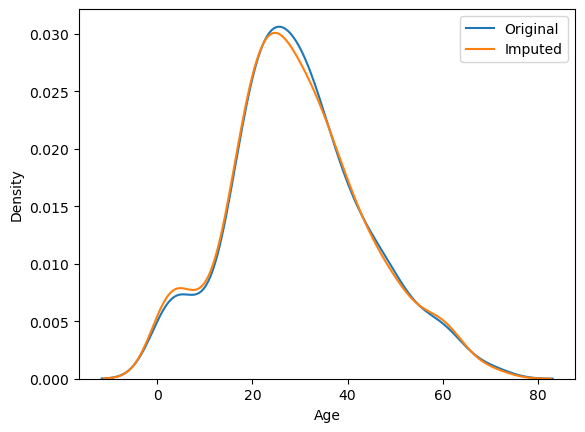

In [27]:
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')

plt.legend()
plt.show()

In [28]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  209.0387067492772


In [29]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,71.227460
Age,71.512440,204.349513,204.349513
Age_imputed,71.227460,204.349513,209.038707


<Axes: >

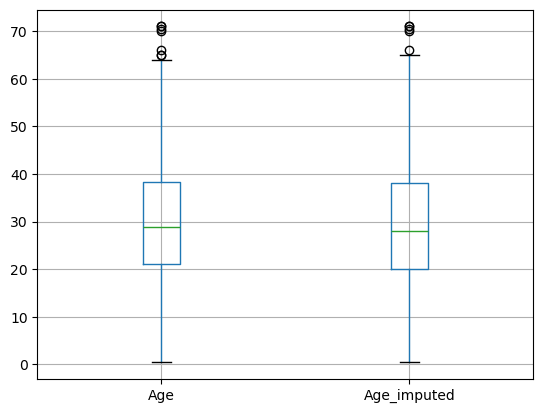

In [30]:
X_train[['Age', 'Age_imputed']].boxplot()

In [22]:
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

# at production level , we need to insure that for same input we get same output and for that we use observation 

NameError: name 'observation' is not defined

In [31]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [32]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [33]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [34]:
X = data
y = data['SalePrice']

In [35]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [36]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [37]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
713,NaN,TA,129000,TA,NaN
1269,NaN,TA,144000,TA,NaN
31,NaN,TA,149350,TA,NaN
227,NaN,TA,106000,TA,NaN
1434,Gd,TA,160000,TA,Gd


In [38]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

C:\Users\hp\AppData\Local\Temp\ipykernel_33088\856878696.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].

In [39]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [40]:
temp

,original,imputed
TA,0.951043,0.950342
Fa,0.037171,0.036815
Gd,0.009973,0.011130
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [41]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.644220
TA,0.412439,0.544332
Fa,0.040917,0.052750
Po,0.027823,0.037037
Ex,0.024550,0.032548


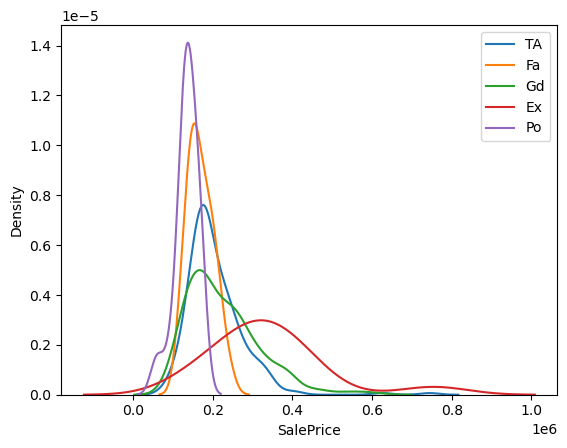

In [43]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(
        X_train[X_train['FireplaceQu'] == category]['SalePrice'],
        label=category
    )

plt.legend()
plt.show()

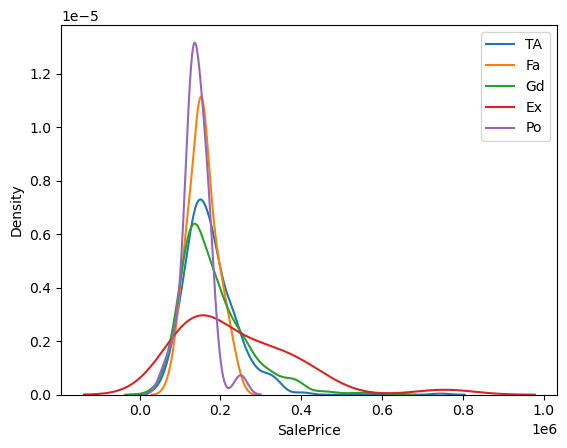

In [44]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],label=category)

plt.legend()
plt.show()